# Maharashtra heatwave severity with KNN
Machine Learning (216H13C501), Exp8 extension · KJS-CES-01

**Operational Heatwave Severity Rules (Project Approximation)**

The high KNN performance is expected because the target labels are generated from two of the model's input variables. The experiment therefore evaluates how effectively KNN approximates our operational decision boundaries, not independent forecasting capability.

Run the acquisition command in the README first. This notebook then prepares the feature handoff, trains the single pipeline, and produces every report figure and table. No synthetic observations are used.

In [1]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from heatwave import INPUT_COLUMNS, LABEL_MAP
from heatwave.pipeline import FeatureBuilder
from heatwave.model import split_by_year, tune_model, save_artifact, load_artifact
from heatwave.evaluate import *
ROOT = Path.cwd() if (Path.cwd() / "heatwave").exists() else Path.cwd().parent
OUT = ROOT / "reports/results"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
def figure(fig, name):
    fig.savefig(OUT / f"{name}.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)
subprocess.run([sys.executable, "-m", "heatwave.cli", "prepare", "--root", str(ROOT)], check=True)
inspection = json.loads((ROOT / "data/processed/inspection.json").read_text())
display(inspection)

{
  "source": "IMD 1-degree annual Tmax GRD",
  "end_year": 2025,
  "grid_cells": 26,
  "baseline_years": [
    1991,
    2014
  ],
  "train_years": [
    2015,
    2022
  ],
  "test_years": [
    2023,
    2024,
    2025
  ],
  "missing_model_rows_dropped": 0,
  "baseline_missing_readings": 0,
  "rows": 34892,
  "byte_order": "little-endian",
  "region_rule_status": "Project geographic proxy; review data/region_lookup.csv"
}
                 train  test
label                       
Normal           25234  9495
Heatwave           142    21
Severe Heatwave      0     0


{'source': 'IMD 1-degree annual Tmax GRD',
 'end_year': 2025,
 'grid_cells': 26,
 'baseline_years': [1991, 2014],
 'train_years': [2015, 2022],
 'test_years': [2023, 2024, 2025],
 'missing_model_rows_dropped': 0,
 'baseline_missing_readings': 0,
 'rows': 34892,
 'byte_order': 'little-endian',
 'region_rule_status': 'Project geographic proxy; review data/region_lookup.csv'}

## Normal and labeling
Normals pool all finite Tmax observations from a ±7-day window in 1991–2014 per cell and fixed calendar day. February 29 is excluded. The normal differs from IMD's official normal. Baseline years precede all model years.

Base thresholds are 40°C for plains, 37°C for coastal and 30°C for hilly. Above the base, departures of 4.5°C and 6.5°C trigger Heatwave and Severe. Where normal ≥40°C, absolute maxima of 45°C and 47°C also trigger those classes. The higher severity wins. These rules are unverified project approximations, applied per cell per day without station-level persistence criteria.

The editable project lookup assigns longitude <74°E to coastal, 74–75°E below 20°N to hilly, and the remainder to plains. This deliberately coarse geographic proxy has no terrain validation. A revised lookup changes target labels and requires the full analysis to be rerun.

In [2]:
features = pd.read_parquet(ROOT / "data/processed/features.parquet")
train, test = split_by_year(features)
counts = class_counts(train, test)
counts.to_csv(OUT / "class_counts.csv")
display(counts)
if counts.loc["Severe Heatwave", "test"] < 30:
    print("CAUTION: fewer than 30 Severe test observations; recall is unstable. This is a project reporting heuristic.")
np.testing.assert_allclose(FeatureBuilder().transform(features).departure, features.departure)
assert pd.to_datetime(train.date).dt.year.max() == 2022
assert pd.to_datetime(test.date).dt.year.min() == 2023
cells = pd.read_csv(ROOT / "data/processed/cells.csv")
display(cells.groupby("region_type").size().rename("grid_cells"))

,train,test
label,,
Normal,25234,9495
Heatwave,142,21
Severe Heatwave,0,0


CAUTION: fewer than 30 Severe test observations; recall is unstable. This is a project reporting heuristic.


region_type
coastal     5
hilly       3
plains     18
Name: grid_cells, dtype: int64

## Search and model handoff
The whole pipeline is refit for each leave-one-year-out fold, including scaling. Search: 13 odd K values, two metrics and two vote weightings, selected by macro-F1 with all three classes explicitly included. Training scores are fold averages. Test data never enters tuning.

Selected: {'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'} CV macro-F1: 0.5533417772004381


,param_knn__n_neighbors,param_knn__metric,param_knn__weights,mean_test_macro_f1,std_test_macro_f1,mean_test_accuracy,rank_test_macro_f1
0,1,euclidean,uniform,0.553342,0.104797,0.996966,1
1,1,euclidean,distance,0.553342,0.104797,0.996966,1
27,1,manhattan,distance,0.553082,0.107341,0.996926,3
26,1,manhattan,uniform,0.553082,0.107341,0.996926,3
31,5,manhattan,distance,0.539065,0.101994,0.996572,5
3,3,euclidean,distance,0.538150,0.101824,0.996453,6
30,5,manhattan,uniform,0.537345,0.102144,0.996453,7
5,5,euclidean,distance,0.536271,0.101689,0.996375,8
4,5,euclidean,uniform,0.535592,0.102361,0.996335,9
7,7,euclidean,distance,0.535433,0.101008,0.996375,10


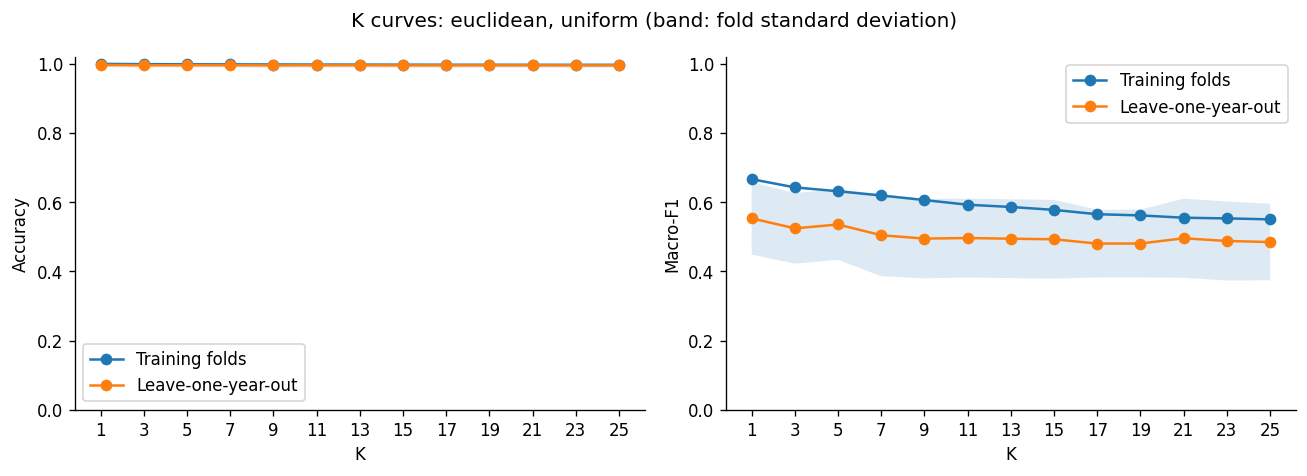

In [3]:
search = tune_model(train, n_jobs=4)
cv = pd.DataFrame(search.cv_results_)
cv.to_csv(ROOT / "data/processed/grid_search.csv", index=False)
cv.to_csv(OUT / "grid_search.csv", index=False)
selected = search.best_params_
model = search.best_estimator_
artifact = save_artifact(model, ROOT / "models/knn_heatwave.joblib", source="IMD", best_params=selected, training_years=list(range(2015, 2023)), baseline_years=[1991, 2014], end_year=inspection["end_year"])
print("Selected:", selected, "CV macro-F1:", search.best_score_)
comparison_columns = ["param_knn__n_neighbors", "param_knn__metric", "param_knn__weights", "mean_test_macro_f1", "std_test_macro_f1", "mean_test_accuracy", "rank_test_macro_f1"]
display(cv[comparison_columns].sort_values("rank_test_macro_f1"))
figure(plot_k_curves(cv), "k_curves")
if selected["knn__metric"] != "euclidean" or selected["knn__weights"] != "uniform":
    figure(plot_k_curves(cv, selected["knn__metric"], selected["knn__weights"]), "k_curves_selected")

## Held-out evaluation
Macro-F1 and Severe recall accompany accuracy and per-class precision/recall/F1. The majority baseline uses the most frequent **training** class. The three test years are evaluated only after model selection.

,macro_f1,severe_recall,accuracy,severe_support
KNN,0.599860,NaN,0.999159,0.0
Majority baseline,0.332965,NaN,0.997793,0.0


KNN


,precision,recall,f1-score,support
Normal,0.999474,0.999684,0.999579,9495.000000
Heatwave,0.842105,0.761905,0.800000,21.000000
Severe Heatwave,0.000000,0.000000,0.000000,0.000000
accuracy,0.999159,0.999159,0.999159,0.999159
macro avg,0.613860,0.587196,0.599860,9516.000000
weighted avg,0.999126,0.999159,0.999138,9516.000000


Majority baseline


,precision,recall,f1-score,support
Normal,0.997793,1.000000,0.998895,9495.000000
Heatwave,0.000000,0.000000,0.000000,21.000000
Severe Heatwave,0.000000,0.000000,0.000000,0.000000
accuracy,0.997793,0.997793,0.997793,0.997793
macro avg,0.332598,0.333333,0.332965,9516.000000
weighted avg,0.995591,0.997793,0.996691,9516.000000


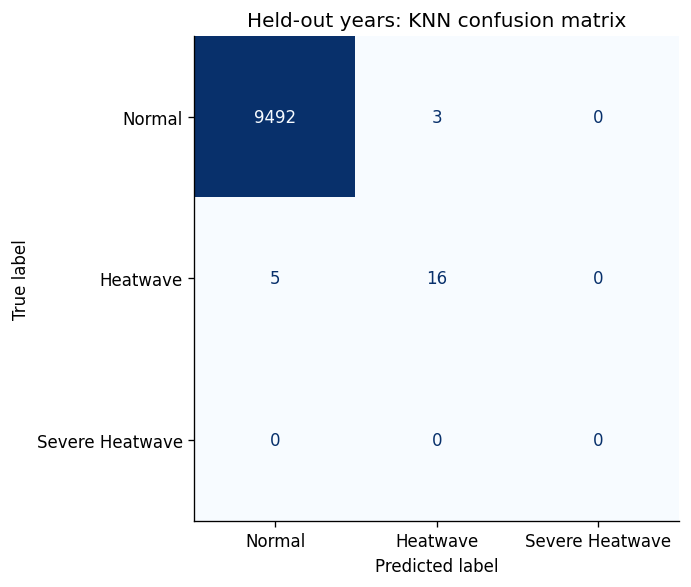

,year,macro_f1,severe_recall,accuracy,severe_support
0,2023,0.599577,NaN,0.997478,0
1,2024,0.333333,NaN,1.000000,0
2,2025,0.333333,NaN,1.000000,0


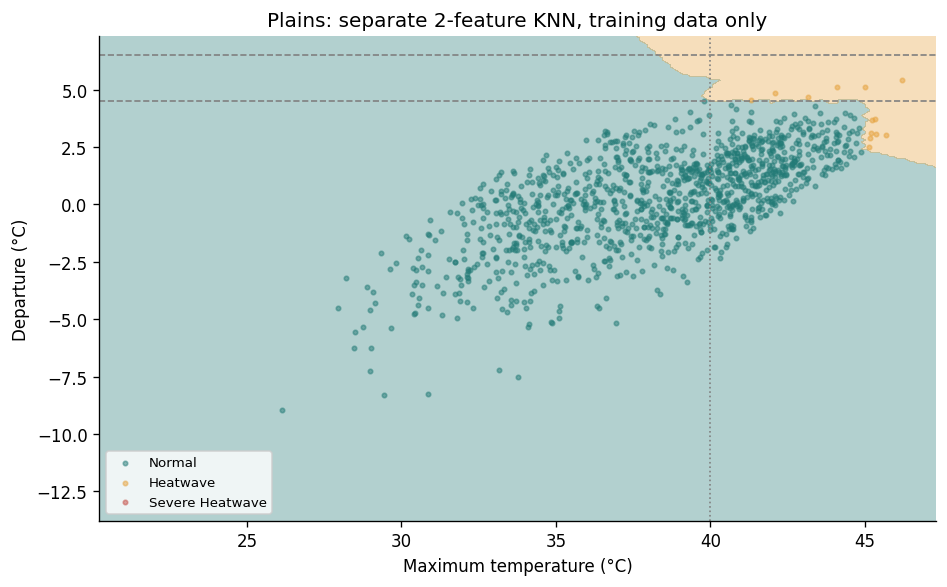

,observations,errors,error_rate
threshold_band,,,
"(-0.001, 0.25]",995,8,0.00804
"(0.25, 0.5]",890,0,0.00000
"(0.5, 1.0]",1684,0,0.00000
"(1.0, 2.0]",2005,0,0.00000
"(2.0, inf]",3942,0,0.00000


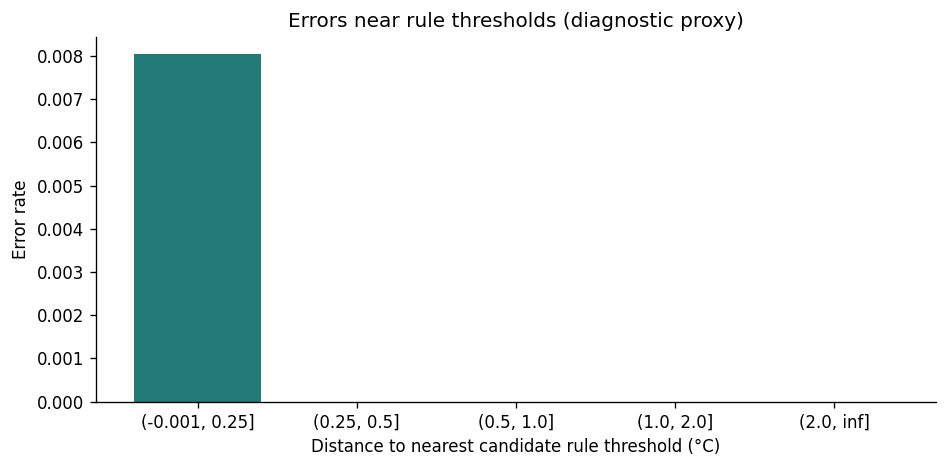

In [4]:
metrics, reports, fig, prediction = evaluate_test(model, train, test)
metrics.to_csv(OUT / "metrics.csv")
display(metrics)
for name, report in reports.items():
    report.to_csv(OUT / ("classification_report.csv" if name == "KNN" else "baseline_report.csv"))
    print(name)
    display(report)
figure(fig, "confusion_matrix")
by_year = pd.DataFrame([{ "year": int(year), **scores(group.label, model.predict(group[INPUT_COLUMNS]))} for year, group in test.groupby(pd.to_datetime(test.date).dt.year)])
by_year.to_csv(OUT / "metrics_by_year.csv", index=False)
display(by_year)
figure(decision_regions(train, k=selected["knn__n_neighbors"], metric=selected["knn__metric"], weights=selected["knn__weights"]), "decision_regions")
errors, bands, fig = boundary_errors(test, prediction)
errors.to_csv(OUT / "prediction_errors.csv", index=False)
bands.to_csv(OUT / "boundary_error_summary.csv")
display(bands)
figure(fig, "boundary_errors")

The decision-region figure uses a **separate two-feature KNN fitted only on plains training observations**. It is not a slice of the deployed six-numeric-feature model. Its background may include combinations absent from the data. Dashed lines mark departure thresholds; the dotted line marks the base threshold.

The error-band distance is a diagnostic proxy to the nearest candidate threshold, not exact distance to the piecewise decision boundary. Candidate normal-temperature and absolute-temperature gates are included.

## Noise robustness
Perturb only held-out maximum temperature, keep normal temperature fixed and recompute departure inside the pipeline. Use σ = 0.5, 1, 2°C and seeds 11, 23, 37, 51, 71. For each odd K, refit on training observations with selected metric and weighting fixed. Reuse the same perturbation across K. Test noise results are diagnostic and do not select the deployed model.

Compare predictions with both original labels and recomputed project rules. The rules-versus-original reference isolates how often the rule target itself changes. Tables preserve each seed, and means/standard deviations summarize them.

,k,sigma,comparison,macro_f1,severe_recall
0,1,0.5,Original labels,0.522878,NaN
1,1,0.5,Recomputed rules,0.562482,0.0
2,1,0.5,Rules vs original,0.497834,NaN
3,1,1.0,Original labels,0.449643,NaN
4,1,1.0,Recomputed rules,0.509223,0.0
...,...,...,...,...,...
112,25,1.0,Recomputed rules,0.395191,0.0
113,25,1.0,Rules vs original,0.403387,NaN
114,25,2.0,Original labels,0.392154,NaN
115,25,2.0,Recomputed rules,0.383246,0.0


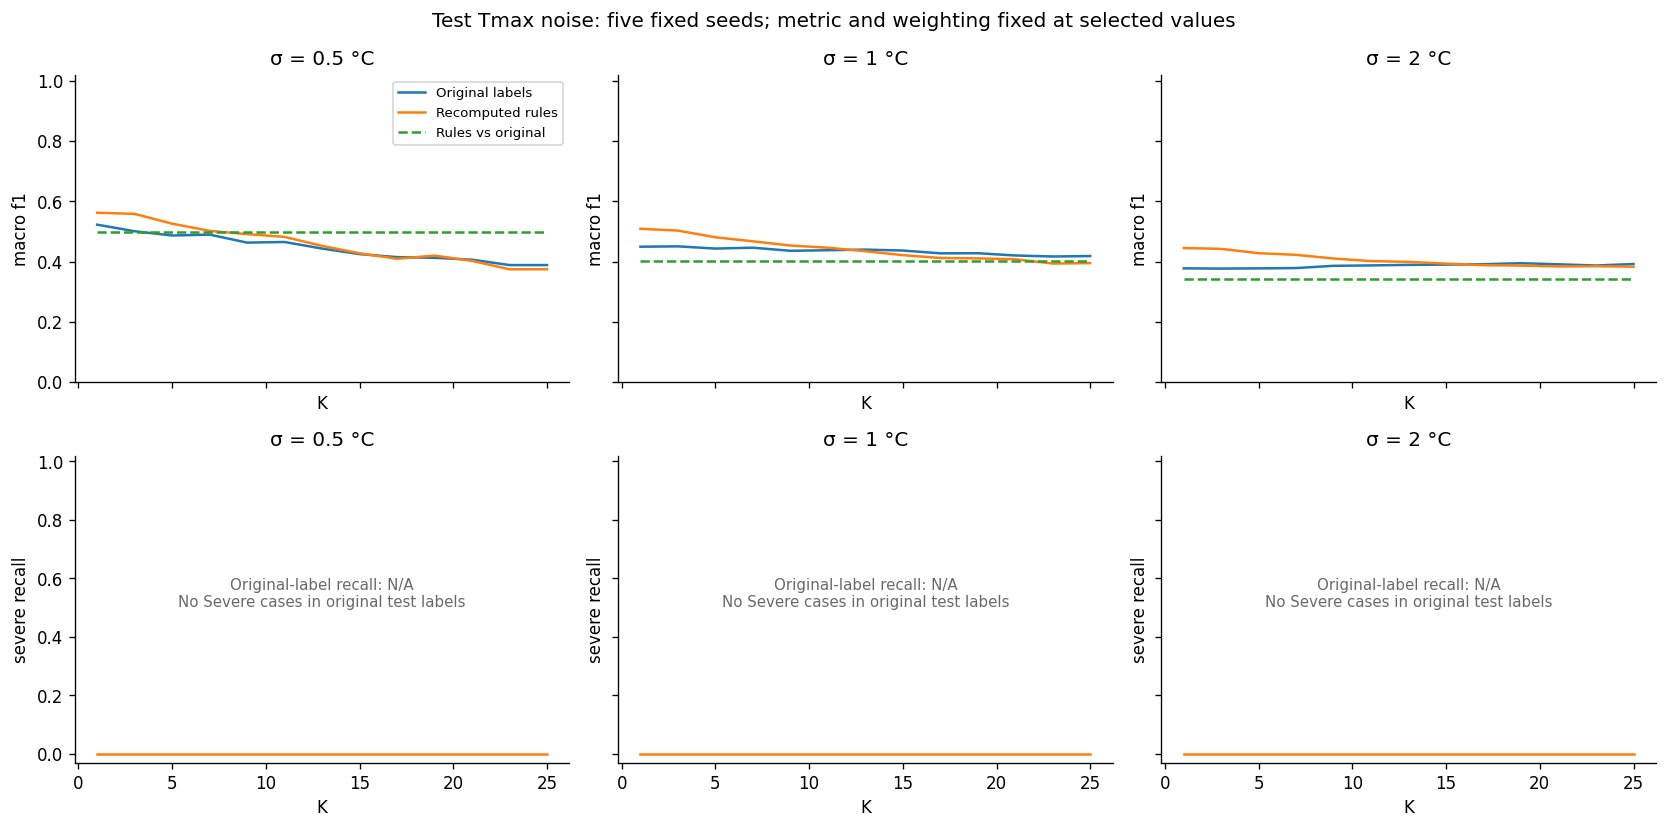

In [5]:
noise = noise_robustness(model, train, test)
noise.to_csv(OUT / "noise_by_seed.csv", index=False)
noise_mean, fig = plot_noise(noise)
noise_mean.to_csv(OUT / "noise_mean.csv", index=False)
noise.groupby(["k", "sigma", "comparison"])[["macro_f1", "severe_recall"]].agg(["mean", "std"]).to_csv(OUT / "noise_summary.csv")
display(noise_mean)
figure(fig, "noise_robustness")

## Saved-results sanity review
Map the region proxy, compare K by fold, and distinguish Heatwave F1 from macro-F1. This section uses saved evidence without fitting.

{'heatwave_f1': 0.8,
 'normal_f1': 0.9995787700084248,
 'supported_macro_f1': 0.8997893850042125,
 'fixed_three_class_macro_f1': 0.5998595900028082,
 'k_curve_best': 1,
 'k_curve_best_score': 0.5533417772004381,
 'k_curve_runner': 5,
 'k_curve_runner_score': 0.5355924482876875,
 'k_curve_gap': 0.017749328912750606,
 'k1_fold_wins': 3,
 'fold_ties': 5,
 'k1_fold_losses': 0,
 'best_metric_gap': 0.00026001646516937704,
 'region_counts': {'plains': 18, 'coastal': 5, 'hilly': 3},
 'all_cells_inside': True,
 'lookup_matches_processed': True,
 'lookup_matches_proxy': True,
 'error_count': 8,
 'max_error_threshold_distance': 0.0701924324035658}

,held_out_year,k1_macro_f1,runner_macro_f1,difference
0,2015,0.626747,0.596901,0.029846
1,2016,0.555503,0.555503,0.000000
2,2017,0.499790,0.499790,0.000000
3,2018,0.640973,0.575600,0.065373
4,2019,0.478827,0.432051,0.046775
5,2020,0.624895,0.624895,0.000000
6,2021,0.333333,0.333333,0.000000
7,2022,0.666667,0.666667,0.000000


,seeds,seeds_with_severe,min_severe_cases,max_severe_cases,mean_defined_severe_recall
sigma,,,,,
0.5,5,4,0,1,0.0
1.0,5,5,2,6,0.0
2.0,5,5,47,68,0.0


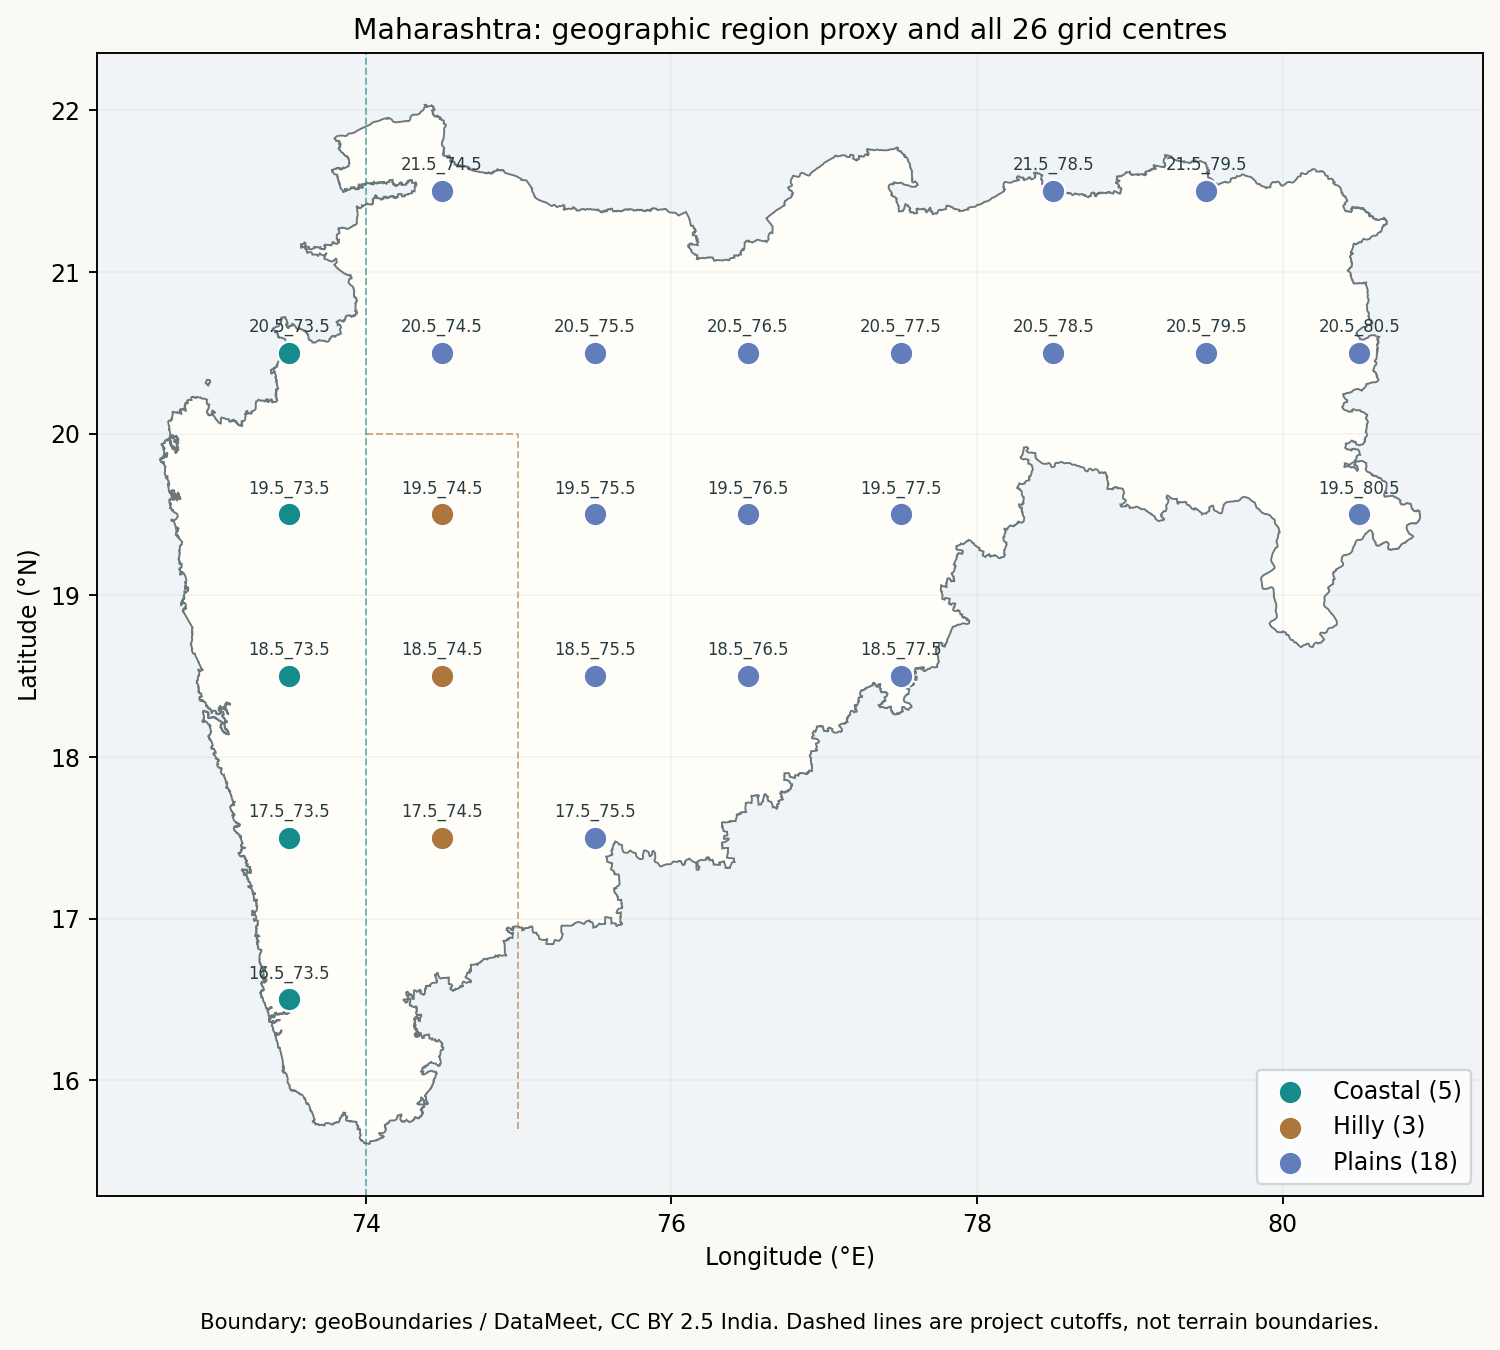

In [ ]:
from heatwave.audit import review_saved_results
review, fold_review, severe_noise_support = review_saved_results(ROOT)
display(review)
display(fold_review)
display(severe_noise_support)
from IPython.display import Image
display(Image(filename=str(OUT / 'region_lookup_map.png')))

## Fresh-process parity and report
The artifact contains the pipeline, label map, input columns and exact scikit-learn version. The app imports the same package and calls the pipeline directly. The neighbor table reports counts and weighted vote shares, which are not calibrated probabilities.

In [6]:
fixed = test[INPUT_COLUMNS].iloc[::max(1, len(test)//20)].head(20)
fixed.to_json(OUT / "parity_inputs.json", orient="table", date_format="iso")
script = "from heatwave.model import load_artifact; import pandas as pd, sys, json; a=load_artifact(sys.argv[1]); x=pd.read_json(sys.argv[2],orient='table'); print(json.dumps(a['pipeline'].predict(x).tolist()))"
actual = json.loads(subprocess.check_output([sys.executable, "-c", script, str(ROOT / "models/knn_heatwave.joblib"), str(OUT / "parity_inputs.json")], text=True))
np.testing.assert_array_equal(model.predict(fixed), actual)
from heatwave.demo import predict_observation
for _, row in fixed.iterrows():
    result = predict_observation(artifact, cells, **row.drop("region_type").to_dict())
    assert result["prediction"] == LABEL_MAP[int(model.predict(row.to_frame().T)[0])]
summary = {"selected": selected, "cv_macro_f1": float(search.best_score_), "inspection": inspection, "parity_rows": len(fixed)}
(OUT / "run_summary.json").write_text(json.dumps(summary, indent=2))
from heatwave.reporting import write_report
write_report(ROOT)
print("Artifact, tables, figures and report are ready.")

Artifact, tables, figures and report are ready.
